In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\Dell\clean_customer_data.csv")

df.head()

,FinancialScore,Region,CustomerGender,CustomerAge,RelationshipTenure,AccountBalance,ActiveProducts,HasCard,IsActiveUser,EstimatedIncome,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
#Customer Segmentation (RFM Style)
# Behavioral Scores
print(df.columns.tolist())

['FinancialScore', 'Region', 'CustomerGender', 'CustomerAge', 'RelationshipTenure', 'AccountBalance', 'ActiveProducts', 'HasCard', 'IsActiveUser', 'EstimatedIncome', 'Churn']


In [45]:
seg_df = df.copy()

In [46]:
# Create Behaviour Scores (RFM-like features)

seg_df = df.copy()

seg_df["TenureScore"] = seg_df["RelationshipTenure"]   # loyalty
seg_df["BalanceScore"] = seg_df["AccountBalance"]      # value
seg_df["ActivityScore"] = seg_df["IsActiveUser"]       # engagement
seg_df["ProductScore"] = seg_df["ActiveProducts"]      # usage depth
seg_df["CardScore"] = seg_df["HasCard"]                # relationship strength


In [47]:
# Select only segmentation features (for clustering)

features = seg_df[[
    "TenureScore",
    "BalanceScore",
    "ActivityScore",
    "ProductScore",
    "CardScore"
]].copy()

# Ensure all values numeric (VERY IMPORTANT for KMeans)
features = features.apply(pd.to_numeric, errors='coerce')

# Optional safety: fill any accidental nulls
features = features.fillna(0)

features.head()

,TenureScore,BalanceScore,ActivityScore,ProductScore,CardScore
0,2,0.00,1,1,1
1,1,83807.86,1,1,0
2,8,159660.80,0,3,1
3,1,0.00,0,2,0
4,2,125510.82,1,1,1


In [48]:
#Scale the data (mandatory for K-Means)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [49]:
#Apply K-Means (4 clusters)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
seg_df["Cluster"] = kmeans.fit_predict(scaled_features)

In [50]:
seg_df["Cluster"].value_counts()

Cluster
3    2897
2    2479
1    2430
0    2194
Name: count, dtype: int64

In [51]:
#Check Behaviour.
seg_df.groupby("Cluster")[[
    "TenureScore",
    "BalanceScore",
    "ActivityScore",
    "ProductScore",
    "CardScore"
]].mean()

,TenureScore,BalanceScore,ActivityScore,ProductScore,CardScore
Cluster,,,,,
0,5.158614,10521.680538,0.525524,2.153145,0.978122
1,5.103292,103848.162753,0.000000,1.258025,1.000000
2,4.914482,105454.889665,1.000000,1.284389,1.000000
3,4.910597,78702.319230,0.524336,1.497066,0.000000


In [52]:
#Assinging labels.
cluster_labels = {
    0: "VIP Customers",
    1: "Potential Loyal",
    2: "At Risk",
    3: "Lost Customers"
}

seg_df["Segment"] = seg_df["Cluster"].map(cluster_labels)

In [53]:
seg_df[["Cluster","Segment"]].head(10)

,Cluster,Segment
0,2,At Risk
1,3,Lost Customers
2,0,VIP Customers
3,3,Lost Customers
4,2,At Risk
5,1,Potential Loyal
6,0,VIP Customers
7,0,VIP Customers
8,3,Lost Customers
9,2,At Risk


In [55]:
seg_df.groupby("Segment")["Churn"].mean()

Segment
At Risk            0.154498
Lost Customers     0.198826
Potential Loyal    0.320576
VIP Customers      0.136281
Name: Churn, dtype: float64

In [57]:
#Segment Visualization & Insights
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

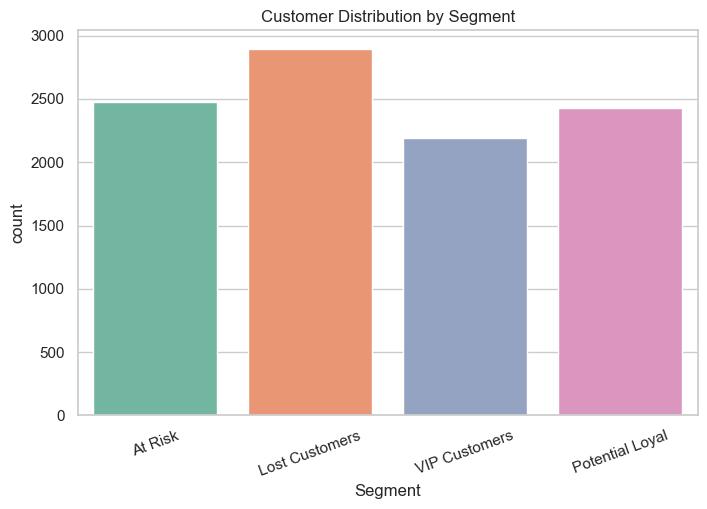

In [58]:
#Customers V/S Segment
plt.figure(figsize=(8,5))
sns.countplot(x="Segment", data=seg_df, palette="Set2")

plt.title("Customer Distribution by Segment")
plt.xticks(rotation=20)
plt.show()

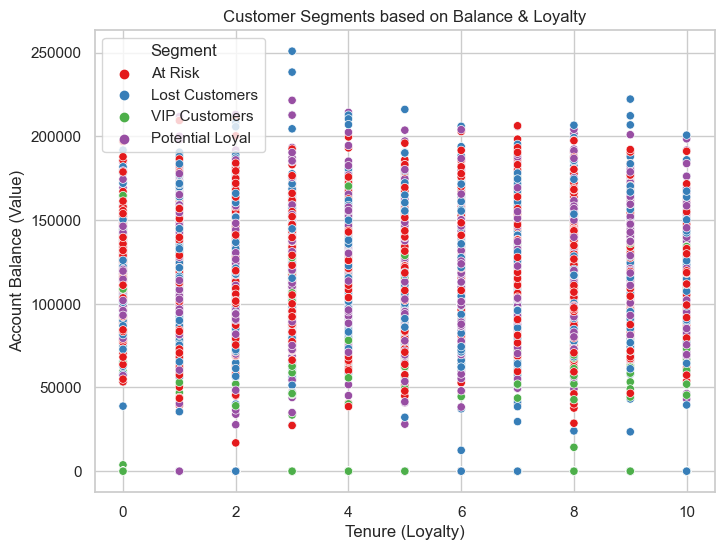

In [59]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=seg_df["TenureScore"],
    y=seg_df["BalanceScore"],
    hue=seg_df["Segment"],
    palette="Set1"
)

plt.title("Customer Segments based on Balance & Loyalty")
plt.xlabel("Tenure (Loyalty)")
plt.ylabel("Account Balance (Value)")
plt.show()

In [60]:
#Activity Heatmap
heatmap_df = seg_df.groupby("Segment")[
    ["TenureScore","BalanceScore","ActivityScore","ProductScore"]
].mean()

In [61]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(heatmap_df)

scaled_heatmap = pd.DataFrame(
    scaled_values,
    columns=heatmap_df.columns,
    index=heatmap_df.index
)

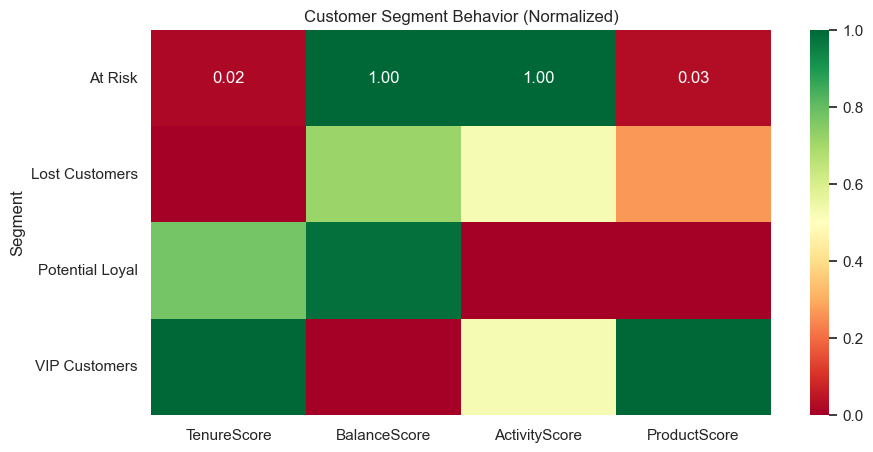

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(scaled_heatmap, annot=True, cmap="RdYlGn", fmt=".2f")

plt.title("Customer Segment Behavior (Normalized)")
plt.show()

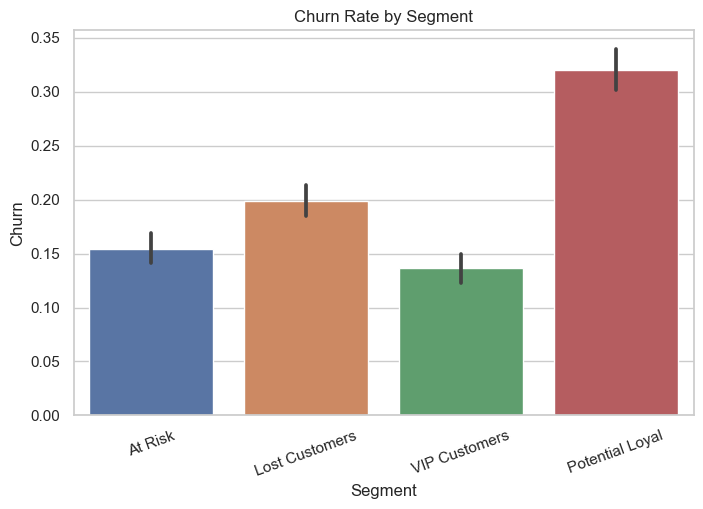

In [63]:
plt.figure(figsize=(8,5))
sns.barplot(x="Segment", y="Churn", data=seg_df)

plt.title("Churn Rate by Segment")
plt.xticks(rotation=20)
plt.show()

In [42]:
seg_df["Churn"].value_counts()

Churn
0    7963
1    2037
Name: count, dtype: int64

In [64]:
seg_df.to_csv(r"C:\Users\Dell\customer_segments.csv", index=False)
print("Segmentation file saved")

Segmentation file saved
